In [ ]:
# Visualize image transformations and predictions from YOLOv8 model on mammo.


from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import pydicom
import cv2

from ultralytics import YOLO


# ============================================================
# PATHS
# ============================================================

DICOM_BASE = Path(
    "/mnt/cafetera/mammo/vindr/images"
)

CSV_PATH = Path(
    "/home/enric_sena/Desktop/prova_enric/vindr_dataset/finding_annotations.csv"
)

DATASET = Path(
    "/home/enric_sena/Desktop/Mammo/Lesion Detection/Yolo v8/vindr_yolo"
)

MODEL_PATH = Path(
    "/home/enric_sena/Desktop/Mammo/runs/detect/train-11/weights/best.pt"
)

IMG_SIZE = 1024
DEVICE = 0

In [ ]:
# Load .csv

df = pd.read_csv(CSV_PATH)

print("CSV:", df.shape)
print(df.columns.tolist())

# Solo test
df_test = df[df["split"] == "test"].copy()

print("Filas test:", len(df_test))

CSV: (20486, 16)
['study_id', 'series_id', 'image_id', 'laterality', 'view_position', 'height', 'width', 'breast_birads', 'breast_density', 'finding_categories', 'finding_birads', 'xmin', 'ymin', 'xmax', 'ymax', 'split']
Filas test: 4095


In [ ]:
#Sample one image. 

idx = 0

row = df_test.iloc[idx]

study_id = row["study_id"]
image_id = row["image_id"]

print("study_id:", study_id)
print("image_id:", image_id)
print("view:", row["view_position"])
print("laterality:", row["laterality"])

study_id: 5683854eafabc34f6d854000d2ac6c2d
image_id: 2f944efb1cb9579442df2d7fe6a579b7
view: CC
laterality: L


In [ ]:
# DICOM route

dicom_path = DICOM_BASE / str(study_id) / f"{image_id}.dicom"

print(dicom_path)
print("Existe:", dicom_path.exists())

/mnt/cafetera/mammo/vindr/images/5683854eafabc34f6d854000d2ac6c2d/2f944efb1cb9579442df2d7fe6a579b7.dicom
Existe: True


In [ ]:
# Read original DICOM 

ds = pydicom.dcmread(dicom_path)

original = ds.pixel_array.astype(np.float32)

print("Shape original:", original.shape)
print("dtype:", original.dtype)
print("min:", original.min())
print("max:", original.max())

Shape original: (3518, 2800)
dtype: float32
min: 0.0
max: 2624.0


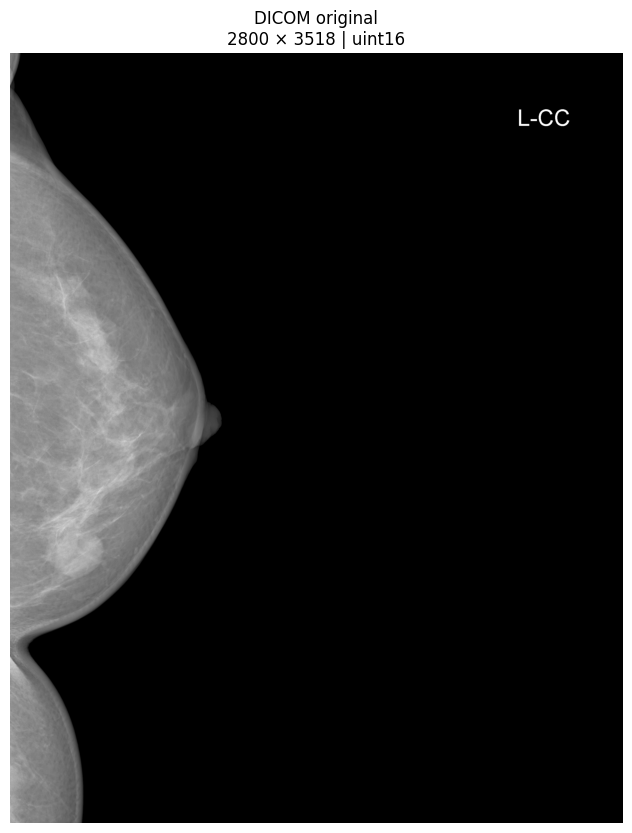

In [ ]:
# Visualize original DICOM

plt.figure(figsize=(8, 10))

plt.imshow(original, cmap="gray")

plt.title(
    f"DICOM original\n"
    f"{original.shape[1]} × {original.shape[0]} | "
    f"{ds.pixel_array.dtype}"
)

plt.axis("off")
plt.show()

In [ ]:
# Preprocess image for the model

img = original.copy()

# ------------------------------------------------------------
# MONOCHROME1
# ------------------------------------------------------------

if getattr(ds, "PhotometricInterpretation", "") == "MONOCHROME1":
    img = img.max() - img


# ------------------------------------------------------------
# NORMALIZACIÓN ROBUSTA 1-99%
# ------------------------------------------------------------

p1, p99 = np.percentile(img, [1, 99])

img = np.clip(
    (img - p1) / (p99 - p1 + 1e-6),
    0,
    1,
)

img = (img * 255).astype(np.uint8)


# ------------------------------------------------------------
# GRAYSCALE → BGR
# ------------------------------------------------------------

img_bgr = cv2.cvtColor(
    img,
    cv2.COLOR_GRAY2BGR
)


# ------------------------------------------------------------
# RESIZE MANTENIENDO ASPECT RATIO
# ------------------------------------------------------------

h0, w0 = img_bgr.shape[:2]

scale = min(
    IMG_SIZE / w0,
    IMG_SIZE / h0
)

new_w = int(round(w0 * scale))
new_h = int(round(h0 * scale))

img_resized = cv2.resize(
    img_bgr,
    (new_w, new_h),
    interpolation=cv2.INTER_LINEAR,
)

print("Original:", (h0, w0))
print("Preprocesada:", img_resized.shape)
print("Scale:", scale)

Original: (3518, 2800)
Preprocesada: (1024, 815, 3)
Scale: 0.2910744741330301


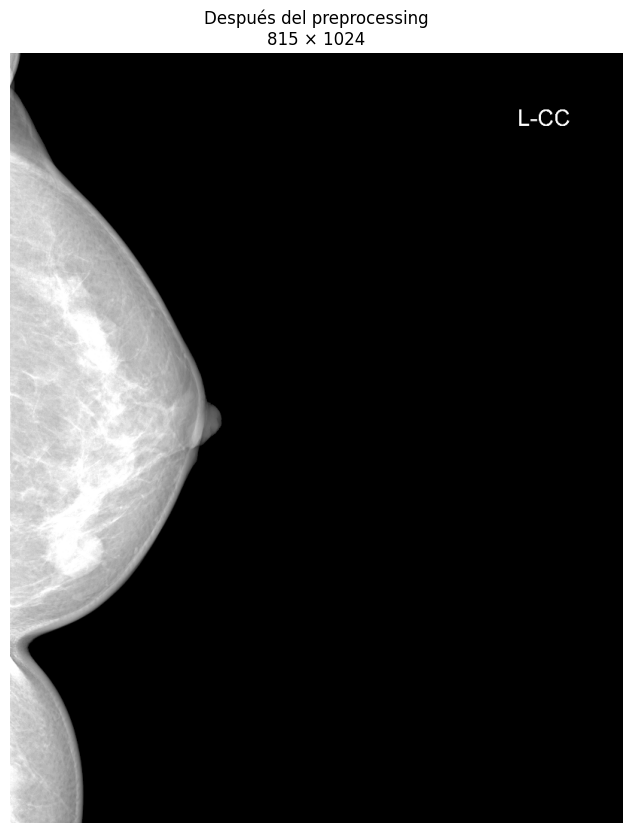

In [ ]:
# Visualize preprocessed image

plt.figure(figsize=(8, 10))

plt.imshow(
    cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB),
    cmap="gray"
)

plt.title(
    f"Después del preprocessing\n"
    f"{new_w} × {new_h}"
)

plt.axis("off")
plt.show()

In [ ]:
# Obtain the Ground Truth bounding boxes for the image

gt = df_test[
    df_test["image_id"] == image_id
].copy()

gt = gt[
    gt[["xmin", "ymin", "xmax", "ymax"]]
    .notna()
    .all(axis=1)
]

print("Bounding boxes:", len(gt))

gt[
    [
        "finding_categories",
        "xmin",
        "ymin",
        "xmax",
        "ymax",
    ]
]

Bounding boxes: 1


,finding_categories,xmin,ymin,xmax,ymax
6,['Mass'],142.899002,2171.810059,439.584991,2403.370117


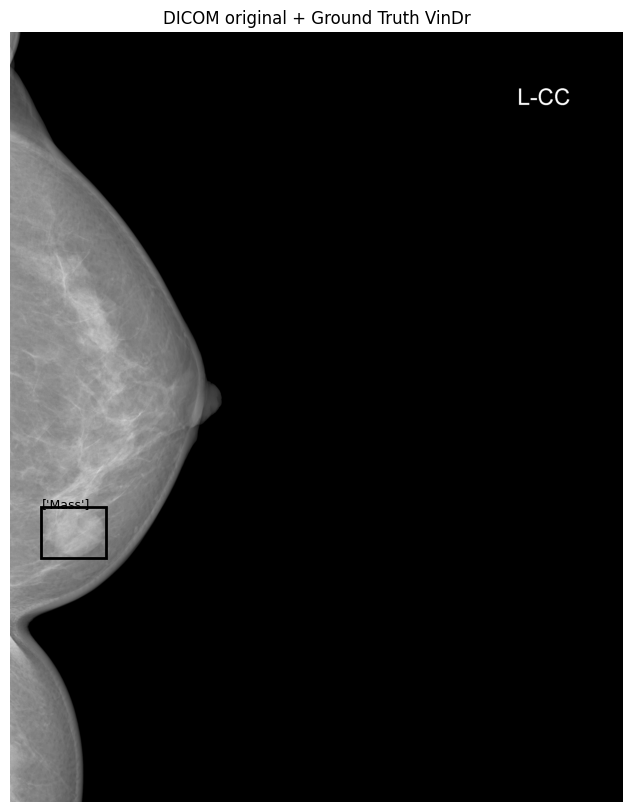

In [ ]:
# Visualize original DICOM + Ground Truth bounding boxes

fig, ax = plt.subplots(figsize=(8, 10))

ax.imshow(original, cmap="gray")

for _, r in gt.iterrows():

    x1 = r["xmin"]
    y1 = r["ymin"]
    x2 = r["xmax"]
    y2 = r["ymax"]

    rect = patches.Rectangle(
        (x1, y1),
        x2 - x1,
        y2 - y1,
        linewidth=2,
        fill=False,
    )

    ax.add_patch(rect)

    ax.text(
        x1,
        y1,
        r["finding_categories"],
        fontsize=9,
    )

ax.set_title(
    "DICOM original + Ground Truth VinDr"
)

ax.axis("off")

plt.show()

In [ ]:
# Resize Ground Truth bounding boxes to match the preprocessed image

gt_resized = gt.copy()

gt_resized["xmin"] *= scale
gt_resized["xmax"] *= scale
gt_resized["ymin"] *= scale
gt_resized["ymax"] *= scale

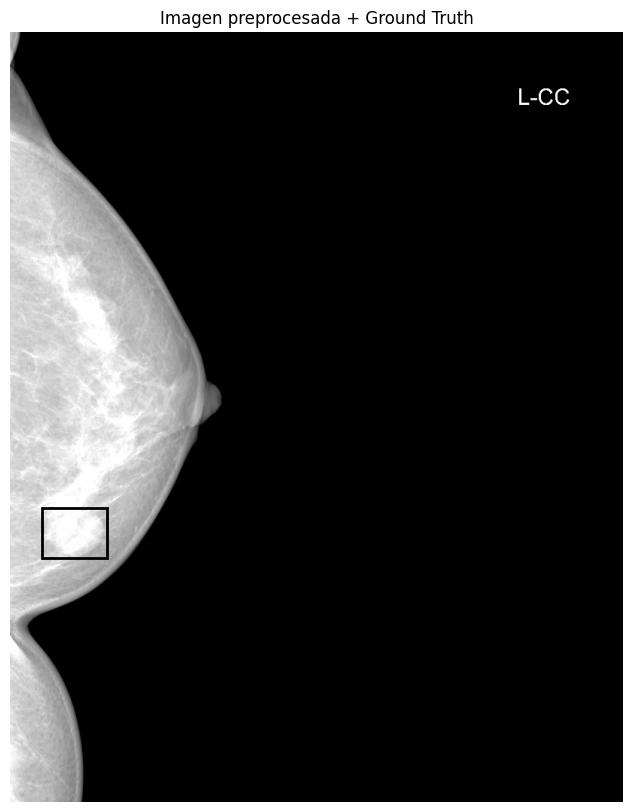

In [ ]:
# Visualize preprocessed image + Ground Truth bounding boxes

fig, ax = plt.subplots(figsize=(8, 10))

ax.imshow(
    cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB)
)

for _, r in gt_resized.iterrows():

    x1 = r["xmin"]
    y1 = r["ymin"]
    x2 = r["xmax"]
    y2 = r["ymax"]

    rect = patches.Rectangle(
        (x1, y1),
        x2 - x1,
        y2 - y1,
        linewidth=2,
        fill=False,
    )

    ax.add_patch(rect)

ax.set_title(
    "Imagen preprocesada + Ground Truth"
)

ax.axis("off")

plt.show()

In [ ]:
# Load YOLOv8 model

model = YOLO(str(MODEL_PATH))

print("Modelo cargado:")
print(MODEL_PATH)

Modelo cargado:
/home/enric_sena/Desktop/Mammo/runs/detect/train-11/weights/best.pt


In [ ]:
# Run inference on the preprocessed image

results = model.predict(
    source=img_resized,
    imgsz=IMG_SIZE,
    conf=0.01,
    iou=0.7,
    device=DEVICE,
    verbose=False,
)

result = results[0]

print("Predicciones:", len(result.boxes))

Predicciones: 1


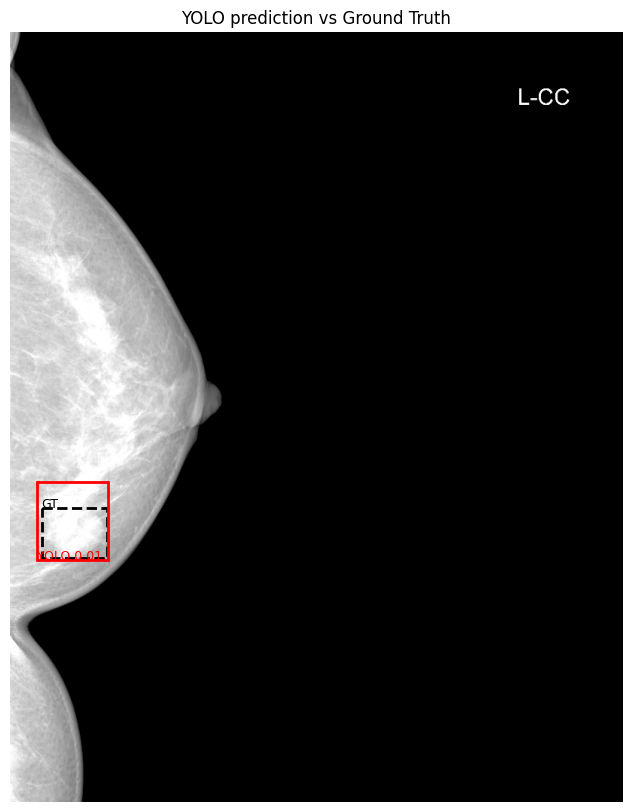

In [21]:
# Visualize preprocessed image + Ground Truth bounding boxes + YOLO predictions

fig, ax = plt.subplots(figsize=(8, 10))

ax.imshow(
    cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB)
)

# ------------------------------------------------------------
# GROUND TRUTH
# ------------------------------------------------------------

for _, r in gt_resized.iterrows():

    x1 = r["xmin"]
    y1 = r["ymin"]
    x2 = r["xmax"]
    y2 = r["ymax"]

    rect = patches.Rectangle(
        (x1, y1),
        x2 - x1,
        y2 - y1,
        linewidth=2,
        fill=False,
        linestyle="--",
    )

    ax.add_patch(rect)

    ax.text(
        x1,
        y1,
        "GT",
        fontsize=9,
    )


# ------------------------------------------------------------
# PREDICCIONES
# ------------------------------------------------------------

if len(result.boxes) > 0:

    boxes = result.boxes.xyxy.cpu().numpy()
    confs = result.boxes.conf.cpu().numpy()

    for box, conf in zip(boxes, confs):

        x1, y1, x2, y2 = box

        rect = patches.Rectangle(
            (x1, y1),
            x2 - x1,
            y2 - y1,
            linewidth=2,
            fill=False,
            color="red"
        )

        ax.add_patch(rect)

        ax.text(
            x1,
            y2,
            f"YOLO {conf:.2f}",
            fontsize=9,
            color = "red"
        )

ax.set_title(
    "YOLO prediction vs Ground Truth"
)

ax.axis("off")

plt.show()

In [ ]:
# Print Ground Truth bounding boxes

print("GROUND TRUTH")
print("=" * 50)

for _, r in gt_resized.iterrows():

    print(
        f"GT: "
        f"({r['xmin']:.1f}, {r['ymin']:.1f}) → "
        f"({r['xmax']:.1f}, {r['ymax']:.1f})"
    )


print()
print("PREDICCIONES YOLO")
print("=" * 50)

if len(result.boxes) == 0:

    print("No hay predicciones")

else:

    boxes = result.boxes.xyxy.cpu().numpy()
    confs = result.boxes.conf.cpu().numpy()

    for box, conf in zip(boxes, confs):

        x1, y1, x2, y2 = box

        print(
            f"YOLO: "
            f"({x1:.1f}, {y1:.1f}) → "
            f"({x2:.1f}, {y2:.1f}) "
            f"conf={conf:.3f}"
        )

GROUND TRUTH
GT: (41.6, 632.2) → (128.0, 699.6)

PREDICCIONES YOLO
YOLO: (35.8, 597.5) → (130.2, 701.2) conf=0.011
